# BING fit on a matchup spectrum (Stage 5)

Fit a PACE `Rrs` spectrum with BING (`pab.fit`) to retrieve IOPs — above all the
non-water backscatter **`b_bp`**, the quantity PAB compares against the BGC-Argo
`BBP700`. This notebook fits a **synthetic, noise-free** spectrum offline (short
MCMC so it runs in seconds and carries committed outputs), shows the posterior
`b_bp` with uncertainties, and persists the fit. A final **`RUN_LIVE`** cell fits
a real Stage-4 matchup.

## 1. A synthetic spectrum with known IOPs

Build `Rrs` from known parameters via BING's own forward model so we can check the retrieval.

truth b_bp(700) = 3.429e-03 m^-1


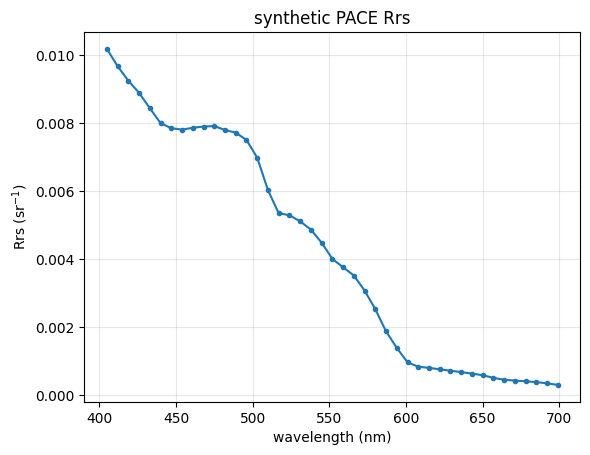

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import bing.evaluate as ev
from bing.models import utils as model_utils
from pab.fit import FitConfig, run

config = FitConfig(nsteps=2000, nburn=500, analysis_burn=500)
wave = np.arange(405.0, 700.0, 7.0)
Chl = 0.1
truth = [0.02, 0.017, 0.03, 0.004, 1.0]   # Adg, Sdg, Aph, Bnw, beta (linear)

_, rt_dict, models = run.build_models(config, wave)
model_utils.init_other_bits(models, Chl=np.array([Chl]), Y=None, Rrs=None)
tp = np.array(truth, float).copy(); ii = 0
for ss in (0, 1):
    for pr in models[ss].priors.priors:
        if pr.flavor.startswith("log"): tp[ii] = np.log10(tp[ii])
        ii += 1
na = models[0].nparam
Rrs = np.squeeze(ev.calc_Rrs_from_models(models[0], tp[:na], models[1], tp[na:], rt_dict))
truth_bbp700 = 0.004 * (600.0/700.0)**1.0
print(f"truth b_bp(700) = {truth_bbp700:.3e} m^-1")
plt.plot(wave, Rrs, "-o", ms=3); plt.xlabel("wavelength (nm)"); plt.ylabel("Rrs (sr$^{-1}$)")
plt.title("synthetic PACE Rrs"); plt.grid(alpha=0.3); plt.show()

## 2. Fit it (LM warm-start → MCMC)

In [2]:
result = run.fit_spectrum(wave, Rrs, 0.02 * Rrs, Chl=Chl, config=config)
print(f"models     : {result.anw_model} + {result.bbnw_model}")
print(f"accept_frac: {result.accept_frac:.2f}   reduced chisq: {result.chisq:.3f}")
for q in result.quantities:
    if q["quantity"] in ("bbp700", "beta", "Bnw"):
        print(f"  {q['quantity']:8s} = {q['value']:.3e}  "
              f"[{q['value_lo']:.3e}, {q['value_hi']:.3e}] {q['unit']}")
bbp700 = next(q for q in result.quantities if q["quantity"] == "bbp700")
print(f"\nretrieved b_bp(700) = {bbp700['value']:.3e}  (truth {truth_bbp700:.3e})")

idx=0
Running burn-in


  0%|          | 0/500 [00:00<?, ?it/s]

 28%|██▊       | 141/500 [00:00<00:00, 1400.44it/s]

 57%|█████▋    | 283/500 [00:00<00:00, 1407.21it/s]

 86%|████████▌ | 428/500 [00:00<00:00, 1424.37it/s]

...

 83%|████████▎ | 1658/2000 [00:01<00:00, 1478.17it/s]

 90%|█████████ | 1809/2000 [00:01<00:00, 1485.84it/s]

 98%|█████████▊| 1958/2000 [00:01<00:00, 1479.36it/s]

100%|██████████| 2000/2000 [00:01<00:00, 1481.28it/s]

models     : ExpBricaud + Pow
accept_frac: 0.49   reduced chisq: 0.015
  Bnw      = 4.009e-03  [3.964e-03, 4.060e-03] 
  beta     = 1.020e+00  [8.971e-01, 1.173e+00] 
  bbp700   = 3.430e-03  [3.376e-03, 3.482e-03] m^-1

retrieved b_bp(700) = 3.430e-03  (truth 3.429e-03)


## 3. Posterior IOPs

The `b_bp(λ)` posterior (median + 90% credible band) from the MCMC chains, and the model `Rrs` at the posterior median vs the observed spectrum.

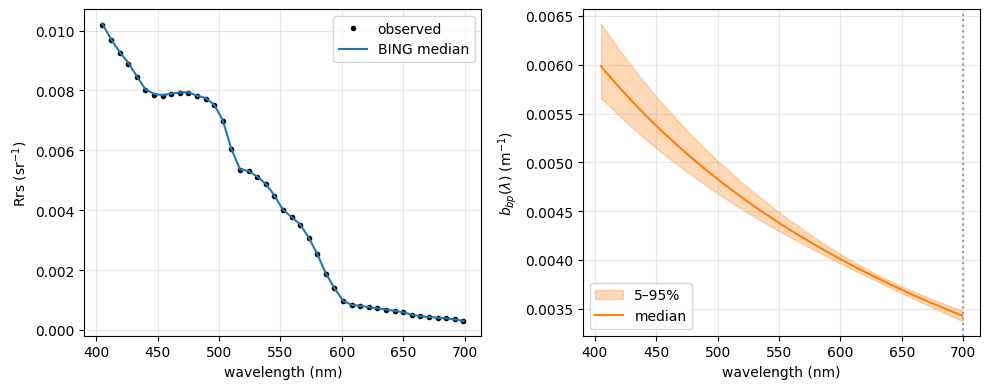

In [3]:
burn = min(config.analysis_burn, result.chains.shape[0] // 2)
flat = ev.thin_burn_chains(result.chains, burn=burn)
bbnw = models[1].eval_bbnw(flat[:, na:], wave=wave)           # (nsamples, nwave)
bbp_med = np.median(bbnw, axis=0); bbp_lo, bbp_hi = np.percentile(bbnw, [5, 95], axis=0)
med_par = np.median(flat, axis=0)
Rrs_pred = np.squeeze(ev.calc_Rrs_from_models(models[0], med_par[:na], models[1], med_par[na:], rt_dict))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
a1.plot(wave, Rrs, "k.", label="observed"); a1.plot(wave, Rrs_pred, "C0-", label="BING median")
a1.set_xlabel("wavelength (nm)"); a1.set_ylabel("Rrs (sr$^{-1}$)"); a1.legend(); a1.grid(alpha=0.3)
a2.fill_between(wave, bbp_lo, bbp_hi, color="C1", alpha=0.3, label="5–95%")
a2.plot(wave, bbp_med, "C1-", label="median"); a2.axvline(700, color="0.6", ls=":")
a2.set_xlabel("wavelength (nm)"); a2.set_ylabel("$b_{bp}(\lambda)$ (m$^{-1}$)"); a2.legend(); a2.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 4. Persist the fit

Write the `fits` + namespaced `fit_results` rows. Here we seed a tiny matchup so the foreign keys resolve; in the pipeline `fit_matchup` / `build_fits` do this from real Stage-4 matchups.

In [4]:
from pab.db import Store
from pab.argo.summary import persist_summary
from pab.fit import artifacts

store = Store.open(":memory:")
pid = persist_summary(store, wmo=7902226, cycle=5,
                      summary={"mld": 30.0, "mld_method": "x", "chla": Chl, "n_points": 6},
                      latitude=20.0, longitude=-50.0, time="2025-05-01T12:00:00")
store.upsert("granules", {"granule_id": "G1", "data_url": "s3://b/G1.nc"})
store.upsert("matchups", {"matchup_id": "7902226_5_G1", "profile_id": pid,
                          "granule_id": "G1", "n_spectra": 1})
store.upsert("matchup_pixels", {"matchup_id": "7902226_5_G1", "ix": 2, "iy": 2,
                                "rank": 1, "flagged": 0})
pixel_id = store.query("SELECT pixel_id FROM matchup_pixels")[0]["pixel_id"]
fit_id = run.make_fit_id("7902226_5_G1", 2, 2, config.model_pair)
artifacts.persist_fit(store, fit_id=fit_id, matchup_id="7902226_5_G1",
                      pixel_id=pixel_id, result=result, config=config,
                      chains_path=f"{fit_id}.npz")
store.fit_results_wide()[[c for c in store.fit_results_wide().columns
                          if c.startswith("BING_ExpBPow_bbp700")]]

quantity,BING_ExpBPow_bbp700,BING_ExpBPow_bbp700_lo,BING_ExpBPow_bbp700_hi
fit_id,,,
7902226_5_G1_2_2_ExpBPow,0.00343,0.003376,0.003482


## 5. (Optional) fit a real matchup

Set `RUN_LIVE = True` to fit a real Stage-4 matchup end-to-end with
`run.fit_matchup` (needs a populated store with matchups + an openable granule;
see notebooks `04`/`05`). Off by default so this notebook builds offline.

In [5]:
RUN_LIVE = False
if RUN_LIVE:
    # `store` must already hold matchups + granules (from the Stage 4 pipeline).
    # fit_id = run.fit_matchup(store, "<matchup_id>", config=FitConfig())
    # print(store.query("SELECT * FROM fits WHERE fit_id = ?", (fit_id,)))
    pass